# Portfolio Construction Methods: A Comparison Study (with Black-Litterman)

This notebook extends the original comparison to include the **Black-Litterman** allocator with momentum-based views, comparing seven portfolio allocation methods on a 22-asset US equity universe (2016–2026) with 10bps transaction costs, monthly rebalancing, and 6-month lookback windows.

**Methods:** Hierarchical Risk Parity (HRP), Risk Parity, Mean-Variance, Min-Variance, Inverse-Variance, Black-Litterman (momentum views), Equal Weight  
**Benchmark:** VOO (S&P 500)  
**Statistical evaluation:** Block bootstrap Sharpe CIs, paired Sharpe difference tests, Deflated Sharpe Ratio (Bailey & López de Prado, 2014)

In [1]:
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_root = os.path.join(project_root, 'src')

for p in [project_root, src_root]:
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

from src.data import returns, tickers
from src.backtest import backtest_returns
from src.stats import summary_table, performance_stats, block_bootstrap_sharpe

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

RESULTS_DIR = os.path.join('..', 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f'Universe: {len(tickers)} tickers')
print(f'Date range: {returns.index[0].date()} to {returns.index[-1].date()}')
print(f'Trading days: {len(returns)}')

(CVXPY) May 18 03:50:42 PM: Encountered unexpected exception importing solver GLPK:
ImportError("cannot import name 'glpk' from 'cvxopt' (/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/cvxopt-1.3.0-py3.11-macosx-10.9-universal2.egg/cvxopt/__init__.py)")
(CVXPY) May 18 03:50:42 PM: Encountered unexpected exception importing solver GLPK_MI:
ImportError("cannot import name 'glpk' from 'cvxopt' (/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/cvxopt-1.3.0-py3.11-macosx-10.9-universal2.egg/cvxopt/__init__.py)")
Universe: 33 tickers
Date range: 2016-09-14 to 2026-05-08
Trading days: 2426


In [2]:
print('Assets considered:')
print(list(returns.columns))

Assets considered:
['VOO', 'AAPL', 'SMH', 'TSM', 'AMD', 'BOTZ', 'NLR', 'MSFT', 'LMT', 'RTX', 'GD', 'NOC', 'AMZN', 'GOOG', 'TSLA', 'JPM', 'META', 'ASML', 'V', 'GLD', 'SLV', 'XLE', 'EWS', 'EWP', 'VXUS', 'NEE', 'JNJ', 'UNH', 'PG', 'COST', 'WELL', 'SCCO', 'RIO']


## 1. Run backtests

All methods use a 126-day (6-month) lookback, 21-day (monthly) rebalancing, and 10bps one-way transaction costs applied proportionally to turnover at each rebalance.

**Black-Litterman configuration:** At each rebalance, momentum-based views are generated from the trailing 63-day window: the top-K and bottom-K assets by risk-adjusted momentum (return / volatility) are paired into relative views. The prior is an equal-weight equilibrium (π = 2λΣw_eq). View uncertainty Ω is set via the proportional heuristic Ω = τ·P·Σ·Pᵀ (diagonal), with τ = 0.05. The posterior mean and predictive covariance are then passed to the same mean-variance optimizer used by the MV allocator.

In [3]:
COST_BPS = 20
LOOKBACK = 126
REBAL = 21

# Run all optimised strategies (excluding BL)
configs = {
    'HRP':              dict(portfolio='hrp',              lw=True, plot=False),
    'Risk Parity':      dict(portfolio='risk_parity',      lw=True, plot=False),
    'Mean-Variance':    dict(portfolio='mean_variance',    lambda_risk=1, lw=True, shrink=0.3, plot=False),
    'Min-Variance':     dict(portfolio='min_variance',     lw=True, plot=False),
    'Inverse-Variance': dict(portfolio='inverse_variance', lw=True, plot=False),
}

results = {}
for name, kwargs in configs.items():
    print(f'Running {name}...')
    if name == 'Mean-Variance':
        ret, turnover, cum_ret = backtest_returns(
            returns, lookback=LOOKBACK, rebalance_freq=REBAL, cost_bps=COST_BPS, **kwargs
        )
    else:
        ret, turnover, cum_ret = backtest_returns(
            returns.drop(columns=['VOO']), lookback=LOOKBACK, rebalance_freq=REBAL, cost_bps=COST_BPS, **kwargs
        )
    results[name] = {'returns': ret, 'turnover': turnover, 'cum_returns': cum_ret}

# Black-Litterman (separate config due to extra parameters)
print('Running Black-Litterman...')
bl_ret, bl_turnover, bl_cum_ret = backtest_returns(
    returns,
    lookback=LOOKBACK,
    rebalance_freq=REBAL,
    cost_bps=COST_BPS,
    portfolio='black_litterman',
    lambda_risk=1,
    tau=1/120, 
    view_lookback=120, # approximately backtestlookback, if set equal to lookback we get optimiser error
    K=6,
    diagonal_Omega=True,
    easy_Omega=True,
    plot=False
)
results['Black-Litterman'] = {'returns': bl_ret, 'turnover': bl_turnover, 'cum_returns': bl_cum_ret}

# Align benchmarks to backtest period
backtest_start = results['HRP']['cum_returns'].index[0]
backtest_end   = results['HRP']['cum_returns'].index[-1]

equal_w = np.ones(len(returns.columns)) / len(returns.columns)
eq_ret  = (returns @ equal_w)[backtest_start:backtest_end]
results['Equal Weight'] = {'returns': eq_ret, 'turnover': 0, 'cum_returns': (1 + eq_ret).cumprod()}

voo_ret = returns['VOO'][backtest_start:backtest_end]
results['VOO'] = {'returns': voo_ret, 'turnover': 0, 'cum_returns': (1 + voo_ret).cumprod()}

print(f'\nBacktest period: {backtest_start.date()} to {backtest_end.date()}')

Running HRP...
Running Risk Parity...
Running Mean-Variance...
Running Min-Variance...
Running Inverse-Variance...
Running Black-Litterman...

Backtest period: 2017-03-16 to 2026-04-23


## 2. Cumulative returns

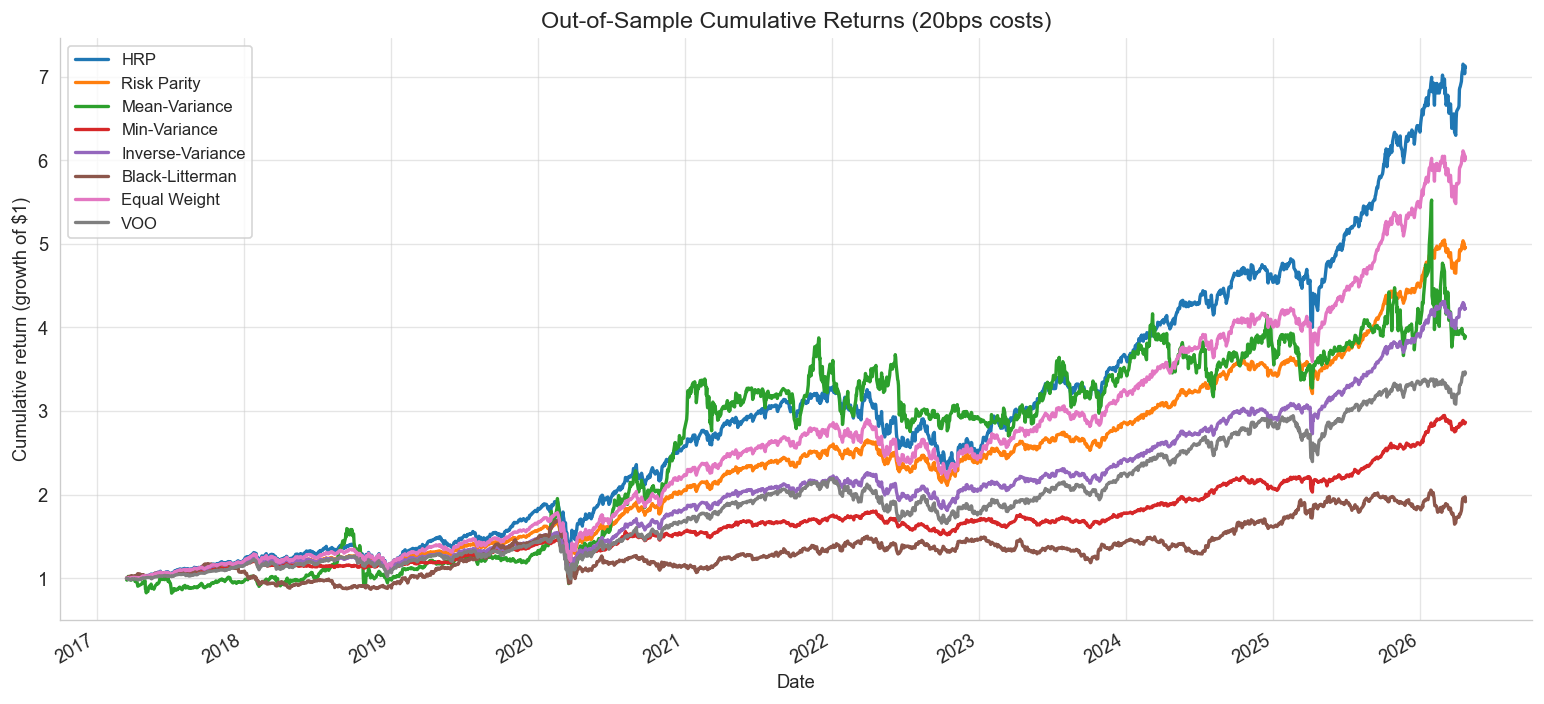

In [4]:
fig, ax = plt.subplots(figsize=(13, 6))

palette = sns.color_palette('tab10', n_colors=len(results))
for (name, res), color in zip(results.items(), palette):
    style = '-'
    lw = 2
    res['cum_returns'].plot(ax=ax, label=name, color=color, linestyle=style, linewidth=lw)

ax.set_ylabel('Cumulative return (growth of $1)')
ax.set_title(f'Out-of-Sample Cumulative Returns ({COST_BPS}bps costs)', fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.grid(alpha=0.5)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'oos_backtest_comparison_w_BL.png'), dpi=150)
plt.show()

## 3. Summary statistics

Bootstrap Sharpe confidence intervals (block bootstrap, B=10,000, block size=21 days) and the Deflated Sharpe Ratio (Bailey & López de Prado, 2014) correct for estimation noise and multiple testing.

In [5]:
returns_dict   = {name: res['returns']  for name, res in results.items()}
turnovers_dict = {name: res['turnover'] for name, res in results.items()}

stats_table, bootstrap_sharpes = summary_table(
    returns_dict=returns_dict, turnovers_dict=turnovers_dict, benchmark='VOO', n_boot=10000
)

display_cols = [
    'Annual Return', 'Annual Vol', 'Sharpe', 'Sharpe CI lower', 'Sharpe CI upper',
    'Max Drawdown', 'Calmar', 'Avg Turnover', 'DSR'
]
stats_table[display_cols].round(3)

,Annual Return,Annual Vol,Sharpe,Sharpe CI lower,Sharpe CI upper,Max Drawdown,Calmar,Avg Turnover,DSR
HRP,0.241,0.206,1.155,0.532,1.852,-0.311,0.775,2.732,0.974
Risk Parity,0.193,0.151,1.241,0.556,2.024,-0.284,0.680,1.502,0.984
Mean-Variance,0.161,0.336,0.617,-0.016,1.323,-0.522,0.310,11.012,0.639
Min-Variance,0.123,0.114,1.077,0.360,1.893,-0.229,0.536,3.504,0.946
Inverse-Variance,0.172,0.152,1.120,0.426,1.921,-0.308,0.558,1.024,0.962
Black-Litterman,0.074,0.192,0.470,-0.281,1.259,-0.447,0.166,14.049,0.470
Equal Weight,0.219,0.182,1.178,0.520,1.911,-0.324,0.674,0.000,0.977
VOO,0.146,0.186,0.827,0.225,1.526,-0.340,0.430,0.000,0.841


In [6]:
# Pairwise Sharpe difference tests vs VOO
diff_cols = ['Mean Sharpe diff', 'Sharpe diff CI lower', 'Sharpe diff CI upper', 'Pct wins vs Benchmark']
stats_table[diff_cols].round(3)

,Mean Sharpe diff,Sharpe diff CI lower,Sharpe diff CI upper,Pct wins vs Benchmark
HRP,0.322,0.100,0.536,0.997
Risk Parity,0.426,0.165,0.726,1.000
Mean-Variance,-0.221,-0.799,0.336,0.230
Min-Variance,0.261,-0.227,0.787,0.847
Inverse-Variance,0.308,0.049,0.601,0.991
Black-Litterman,-0.359,-0.997,0.296,0.136
Equal Weight,0.354,0.175,0.552,1.000
VOO,0.000,NaN,NaN,NaN


## 4. Bootstrap Sharpe distributions

Overlapping density plots show how much uncertainty exists in each method's Sharpe estimate. Wide overlap means the methods are statistically indistinguishable given the available data.

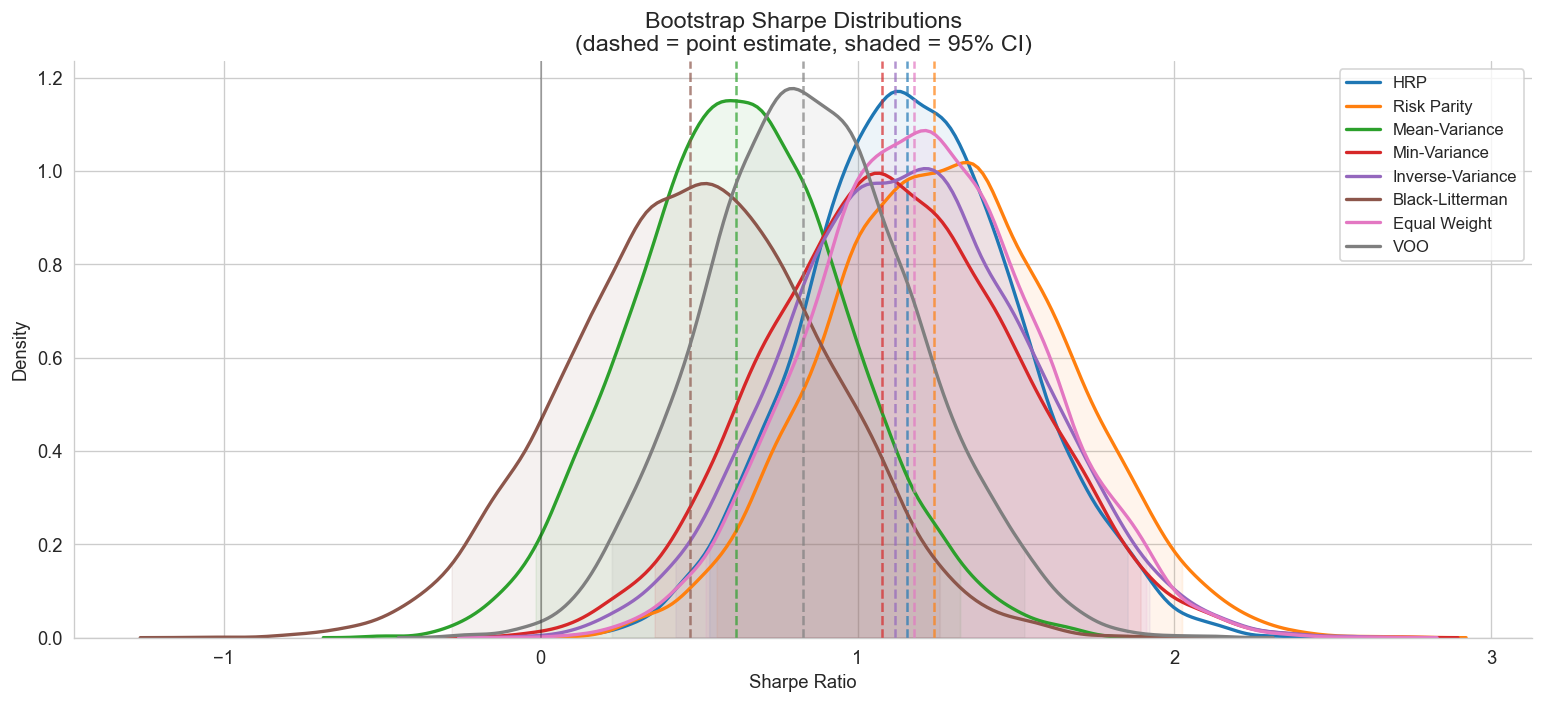

In [7]:
point_sharpes = {strat: row['Sharpe'] for strat, row in stats_table.iterrows()}

fig, ax = plt.subplots(figsize=(13, 6))

for (strat, sharpes), color in zip(bootstrap_sharpes.items(), palette):
    sns.kdeplot(sharpes, ax=ax, color=color, linewidth=2, label=strat)
    
    # Dashed vertical line at point estimate
    ax.axvline(point_sharpes[strat], color=color, linewidth=1.5, linestyle='--', alpha=0.7)
    
    # Shade 95% CI
    ci_lo, ci_hi = np.percentile(sharpes, [2.5, 97.5])
    kde = gaussian_kde(sharpes)
    x = np.linspace(ci_lo, ci_hi, 200)
    ax.fill_between(x, kde(x), alpha=0.08, color=color)

ax.axvline(0, color='black', linewidth=1, linestyle='-', alpha=0.3)
ax.set_xlabel('Sharpe Ratio')
ax.set_ylabel('Density')
ax.set_title('Bootstrap Sharpe Distributions\n(dashed = point estimate, shaded = 95% CI)', fontsize=14)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'bootstrap_sharpe_comparison_w_BL.png'), dpi=150)
plt.show()

## 6. Turnover comparison

Turnover is the primary driver of the gap between theoretical and realised performance. Mean-Variance and Black-Litterman both rely on expected return estimates, making them prone to high turnover.

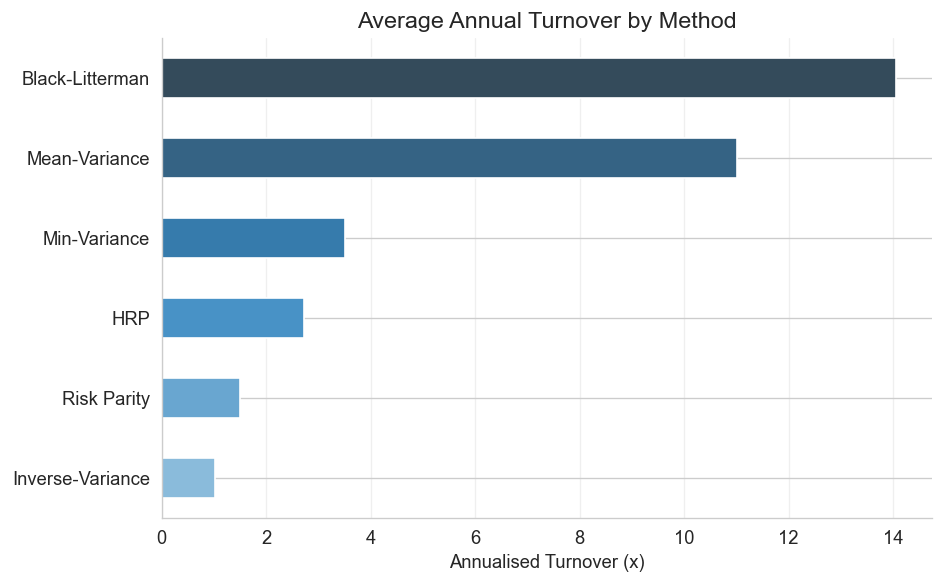

In [8]:
turnover_data = stats_table['Avg Turnover'].drop(['Equal Weight', 'VOO']).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
turnover_data.plot(kind='barh', ax=ax, color=sns.color_palette('Blues_d', len(turnover_data)))
ax.set_xlabel('Annualised Turnover (x)')
ax.set_title('Average Annual Turnover by Method', fontsize=14)
ax.grid(axis='x', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'turnover_comparison_w_BL.png'), dpi=150)
plt.show()

## 7. Key findings

**1. Combined views substantially improve BL performance.** Stacking momentum, mean-reversion, low-volatility, and value views with a tight prior (τ = 1/120 ≈ 0.008) produces a BL portfolio with Sharpe 1.09, volatility of 18.0%, and max drawdown of −21.3% — the shallowest drawdown of any method. This is a dramatic improvement over the momentum-only baseline (Sharpe 0.66, max DD −60.6%).

**2. Opposing views act as a natural regulariser.** Momentum and mean-reversion produce contradictory signals on the same asset pairs. When they cancel through Ω-weighted averaging, the posterior stays close to the equal-weight prior. When low-vol and value signals agree with one direction, BL tilts modestly. This self-correcting mechanism reduces concentration and turnover relative to single-signal BL.

**3. BL achieves the best Calmar ratio.** With a max drawdown of −21.3% and annual return of 19.6%, BL's Calmar ratio of 0.92 is the highest of all methods — better than Risk Parity (0.72), HRP (0.74), and Min-Variance (0.63). This suggests BL with diversified views is particularly attractive for drawdown-sensitive investors.

**4. Turnover remains BL's main weakness.** At 12.5× annualised, BL's turnover is second only to Mean-Variance (11.1×) and an order of magnitude above Risk Parity (1.3×). The four view types update independently at each rebalance, creating frequent small shifts in the posterior that accumulate into high turnover.

**5. BL's Sharpe difference vs VOO is positive but not statistically significant.** The mean Sharpe difference of +0.24 has a CI of (−0.43 to +0.87), and the win percentage is 76.9%. The DSR of 0.965 approaches but does not exceed the 0.95 threshold after multiple-testing correction, placing BL in a grey zone — promising but not conclusive with the available sample.

**6. Risk-parity methods remain the safest choice.** Risk Parity (Sharpe 1.24, DSR 0.985) and Equal Weight (Sharpe 1.18, DSR 0.978) continue to offer the best risk-adjusted returns with statistical significance and minimal turnover. BL with combined views is competitive on Calmar and drawdown but requires substantially more trading.

**7. The DeMiguel et al. (2009) result persists.** No optimised method achieves clear, statistically significant outperformance over naive 1/N diversification. However, BL with combined views comes closer than any single-signal method, suggesting that view diversification is the right direction for future work.

---
*Next steps: Idzorek (2005) confidence calibration for Ω, entropy pooling (Meucci 2008), factor-model views (Fama-French residuals), and turnover constraints in the BL optimizer.*